In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

path_file = "../data/vgsales.csv"
df = pd.read_csv(path_file)
print("Raw shape:", df.shape)

Raw shape: (16598, 11)


In [3]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
df = df.dropna(subset=['Year']).copy()
df = df[df['Year'] <= 2016]
print("Shape after Year filtering:", df.shape)
def assign_era(year):
    year = int(year)
    if 1980 <= year <= 1989:
        return '1980s'
    if 1990 <= year <= 1999:
        return '1990s'
    if 2000 <= year <= 2009:
        return '2000s'
    if 2010 <= year <= 2016:
        return '2010s'
    return np.nan
df['Era'] = df['Year'].apply(assign_era)
era_order = ['1980s', '1990s', '2000s', '2010s']
df['Era'] = pd.Categorical(df['Era'], categories=era_order, ordered=True)
print(df['Era'].value_counts().reindex(era_order))

Shape after Year filtering: (16323, 11)
Era
1980s     205
1990s    1769
2000s    9208
2010s    5141
Name: count, dtype: int64


In [5]:
print("Missing Publisher rows:", df['Publisher'].isna().sum())


Missing Publisher rows: 36


In [6]:
genre_pivot = df.pivot_table(index='Era', columns='Genre', values='Global_Sales',
                              aggfunc='sum', observed=True)
genre_share = genre_pivot.div(genre_pivot.sum(axis=1), axis=0) * 100
genre_share = genre_share.round(2)
genre_share


Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
Era,,,,,,,,,,,,
1980s,13.59,1.27,1.92,2.24,32.47,16.66,3.21,4.05,15.88,0.14,8.57,NaN
1990s,10.89,3.50,9.65,4.97,16.34,3.05,11.76,14.43,5.39,4.07,11.46,4.49
2000s,18.49,2.67,4.98,10.50,8.12,2.57,9.49,9.01,9.36,5.73,17.35,1.72
2010s,26.72,2.42,3.26,9.44,4.79,0.84,4.91,12.13,18.36,2.82,12.89,1.42


In [7]:
growth = (genre_share.loc['2010s'] - genre_share.loc['1980s']).sort_values(ascending=False)
print("Market-share change in percentage points, 1980s -> 2010s:\n")
print(growth.round(2))
print("\nTop gainers:")
print(growth.head(3))
print("\nTop losers:")
print(growth.tail(3))


Market-share change in percentage points, 1980s -> 2010s:

Genre
Action          13.13
Role-Playing     8.08
Misc             7.20
Sports           4.32
Simulation       2.68
Shooter          2.48
Racing           1.70
Fighting         1.34
Adventure        1.15
Puzzle         -15.82
Platform       -27.68
Strategy          NaN
dtype: float64

Top gainers:
Genre
Action          13.13
Role-Playing     8.08
Misc             7.20
dtype: float64

Top losers:
Genre
Puzzle     -15.82
Platform   -27.68
Strategy      NaN
dtype: float64


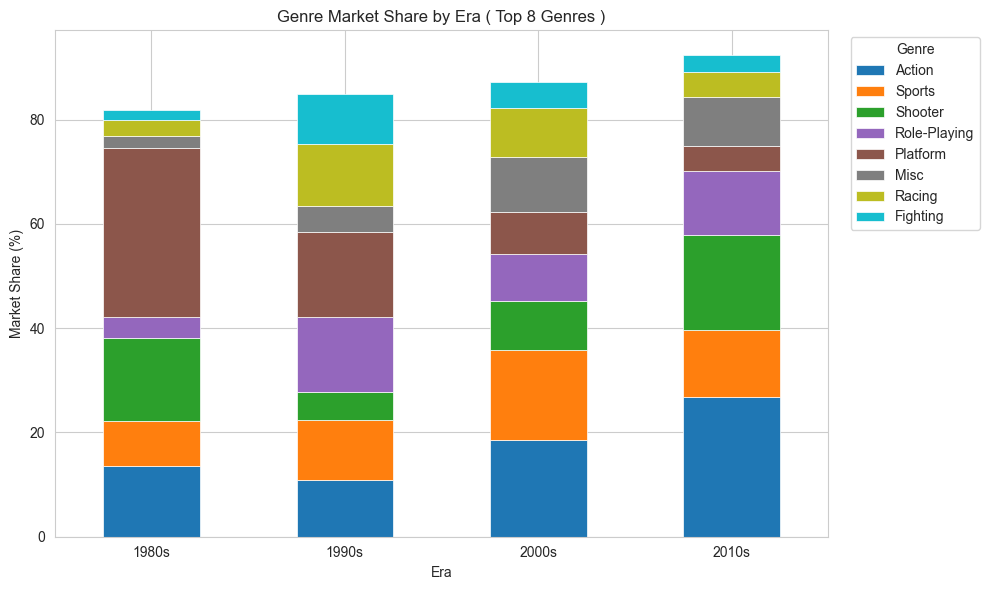

In [8]:
top8_genres = genre_pivot.sum(axis=0).sort_values(ascending=False).head(8).index
plot_data = genre_share[top8_genres]
fig, ax = plt.subplots(figsize=(10, 6))
plot_data.loc[era_order].plot(kind='bar', stacked=True, ax=ax,
                               colormap='tab10', edgecolor='white', linewidth=0.5)
ax.set_ylabel('Market Share (%)')
ax.set_xlabel('Era')
ax.set_title('Genre Market Share by Era ( Top 8 Genres )')
ax.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('genre_share_stacked_bar.png')
plt.show()

In [9]:
platform_pivot = df.pivot_table(index='Era', columns='Platform', values='Global_Sales',
                                 aggfunc='sum', observed=True)
platform_share = platform_pivot.div(platform_pivot.sum(axis=1), axis=0) * 100
platform_share = platform_share.round(2)
for era in era_order:
    print(f"--- {era}: top 3 platforms by market share ---")
    print(platform_share.loc[era].sort_values(ascending=False).head(3))
    print()

--- 1980s: top 3 platforms by market share ---
Platform
NES     59.36
2600    22.99
GB      17.64
Name: 1980s, dtype: float64

--- 1990s: top 3 platforms by market share ---
Platform
PS      45.89
SNES    15.64
N64     14.14
Name: 1990s, dtype: float64

--- 2000s: top 3 platforms by market share ---
Platform
PS2    26.43
DS     14.84
Wii    14.59
Name: 2000s, dtype: float64

--- 2010s: top 3 platforms by market share ---
Platform
PS3     23.90
X360    22.10
PS4     11.03
Name: 2010s, dtype: float64



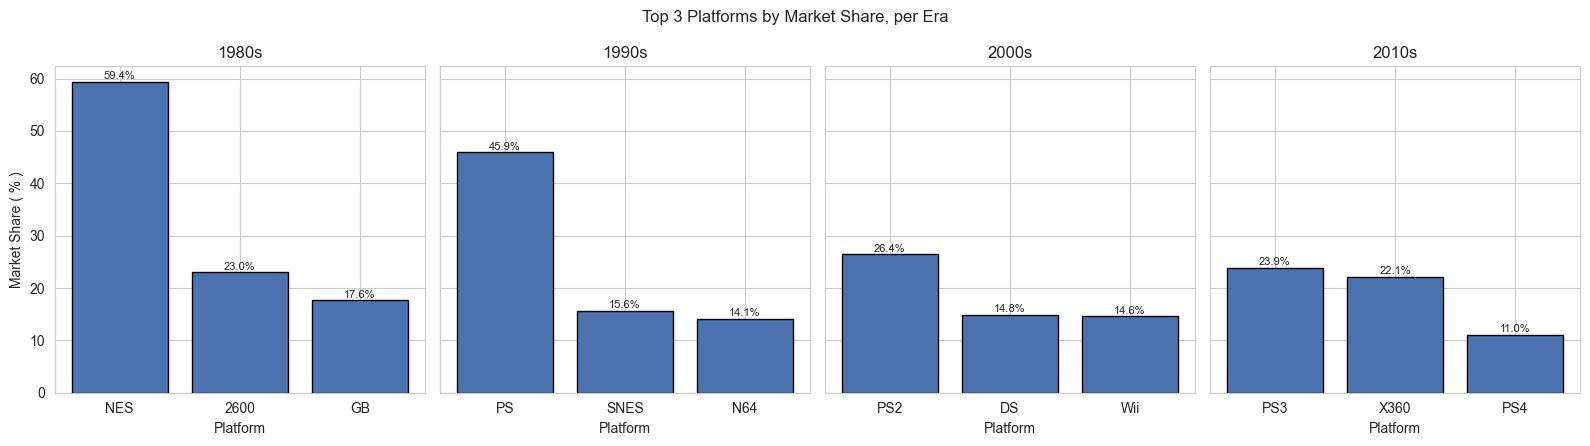

In [10]:
top_platforms_per_era = {}
for era in era_order:
    top_platforms_per_era[era] = platform_share.loc[era].sort_values(ascending=False).head(3)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True)
for ax, era in zip(axes, era_order):
    s = top_platforms_per_era[era]
    ax.bar(s.index, s.values, color='#4C72B0', edgecolor='black')
    ax.set_title(era)
    ax.set_xlabel('Platform')
    for i, v in enumerate(s.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8)
axes[0].set_ylabel('Market Share ( % )')
fig.suptitle('Top 3 Platforms by Market Share, per Era')
plt.tight_layout()
plt.savefig('platform_share_per_era.png')
plt.show()

In [11]:
df_pub = df.dropna(subset=['Publisher'])
era_totals = df_pub.groupby('Era', observed=True)['Global_Sales'].sum()
pub_era_sales = (
    df_pub.groupby(['Era', 'Publisher'], observed=True)['Global_Sales']
    .sum()
    .reset_index()
)
top3_by_era = {}
for era in era_order:
    sub = pub_era_sales[pub_era_sales['Era'] == era].sort_values('Global_Sales', ascending=False).head(3).copy()
    sub['Share_%'] = (sub['Global_Sales'] / era_totals[era] * 100).round(1)
    top3_by_era[era] = sub.reset_index(drop=True)
    print(f"--- {era} ---")
    print(sub[['Publisher', 'Global_Sales', 'Share_%']].to_string(index=False))
    print()

--- 1980s ---
 Publisher  Global_Sales  Share_%
  Nintendo        234.92     62.4
     Atari         41.30     11.0
Activision         18.41      4.9

--- 1990s ---
                  Publisher  Global_Sales  Share_%
                   Nintendo        364.56     28.5
Sony Computer Entertainment        171.73     13.4
            Electronic Arts         84.98      6.6

--- 2000s ---
      Publisher  Global_Sales  Share_%
       Nintendo        883.89     19.1
Electronic Arts        647.49     14.0
     Activision        381.45      8.2

--- 2010s ---
      Publisher  Global_Sales  Share_%
Electronic Arts        360.92     14.3
       Nintendo        301.06     11.9
     Activision        295.65     11.7



In [12]:
all_top_publishers = set()
for era in era_order:
    all_top_publishers |= set(top3_by_era[era]['Publisher'])
presence = {}
for pub in sorted(all_top_publishers):
    eras_present = [era for era in era_order if pub in top3_by_era[era]['Publisher'].values]
    presence[pub] = eras_present
presence_df = pd.DataFrame([
    {'Publisher': pub, 'Eras_in_Top3': ', '.join(eras), 'Era_Count': len(eras)}
    for pub, eras in presence.items()
]).sort_values('Era_Count', ascending=False).reset_index(drop=True)
presence_df

,Publisher,Eras_in_Top3,Era_Count
0,Nintendo,"1980s, 1990s, 2000s, 2010s",4
1,Activision,"1980s, 2000s, 2010s",3
2,Electronic Arts,"1990s, 2000s, 2010s",3
3,Atari,1980s,1
4,Sony Computer Entertainment,1990s,1


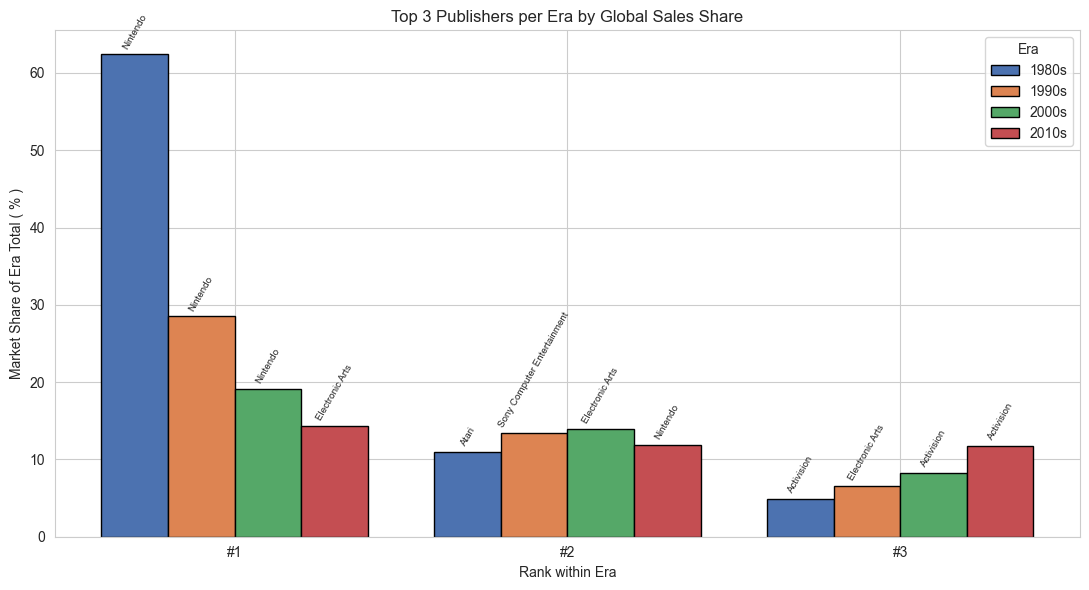

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
bar_width = 0.2
x = np.arange(3)  
colors = {'1980s': '#4C72B0', '1990s': '#DD8452', '2000s': '#55A868', '2010s': '#C44E52'}
for i, era in enumerate(era_order):
    sub = top3_by_era[era]
    offsets = x + (i - 1.5) * bar_width
    bars = ax.bar(offsets, sub['Share_%'], width=bar_width, label=era, color=colors[era], edgecolor='black')
    for bar, pub in zip(bars, sub['Publisher']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, pub,
                ha='center', va='bottom', fontsize=7, rotation=60)
ax.set_xticks(x)
ax.set_xticklabels(['#1', '#2', '#3'])
ax.set_ylabel('Market Share of Era Total ( % )')
ax.set_xlabel('Rank within Era')
ax.set_title('Top 3 Publishers per Era by Global Sales Share')
ax.legend(title='Era')
plt.tight_layout()
plt.savefig('top_publishers_per_era.png')
plt.show()

In [14]:
genre_totals = genre_pivot  # absolute $M sales  ,   not   %
cagr = ((genre_totals.loc['2010s'] / genre_totals.loc['1980s']) ** (1/3) - 1) * 100
cagr = cagr.replace([np.inf, -np.inf], np.nan).sort_values(ascending=False)
print("CAGR % per decade-transition, 1980s -> 2010s ( Global_Sales ):\n")
print(cagr.round(1))

CAGR % per decade-transition, 1980s -> 2010s ( Global_Sales ):

Genre
Simulation      418.4
Misc            204.3
Role-Playing    171.6
Action          136.1
Adventure       133.8
Fighting        124.6
Racing          117.0
Sports          115.9
Shooter          97.8
Platform         -0.4
Puzzle          -30.3
Strategy          NaN
dtype: float64


In [15]:
genre_region = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()
genre_region['NA_EU_ratio'] = genre_region['NA_Sales'] / genre_region['EU_Sales']
genre_region['JP_NA_ratio'] = genre_region['JP_Sales'] / genre_region['NA_Sales']
print("Most NA-dominant genres ( highest NA/EU ratio ):")
print(genre_region['NA_EU_ratio'].sort_values(ascending=False).head(3).round(2))
print("\nMost Japan-dominant genres ( highest JP/NA ratio ):")
print(genre_region['JP_NA_ratio'].sort_values(ascending=False).head(3).round(2))

Most NA-dominant genres ( highest NA/EU ratio ):
Genre
Puzzle      2.41
Platform    2.22
Fighting    2.21
Name: NA_EU_ratio, dtype: float64

Most Japan-dominant genres ( highest JP/NA ratio ):
Genre
Role-Playing    1.07
Strategy        0.72
Adventure       0.51
Name: JP_NA_ratio, dtype: float64


In [16]:
df.to_csv('vgsales_with_era.csv', index=False)
print("Saved:", df.shape)

Saved: (16323, 12)
